In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import os, pickle, torch
import tqdm
import vima
torch.set_default_device('mps') # edit as appropriate to hardware
vima.set_seed(0) # for reproducibility
os.makedirs(f'./_results', exist_ok=True)
%run ../common.py

In [107]:
# read in samples
repname = 'pca_k=10_harmony'
samples = vima.read_samples(f'../../ALZ/alz-data/10u/{repname}/*.nc', vima.default_parser)

# read in sample metadata
samplemeta = pd.read_csv('../../ALZ/alz-data/sea-ad_cohort_donor_metadata_encoded_20240924.tsv',
                         sep='\t').set_index('Donor ID', drop=True)
samplemeta['case'] = samplemeta['Consensus Clinical Dx (choice=Control)'] != 'Checked'

100%|███████████████████████████████████████████████████████████████| 75/75 [00:09<00:00,  7.52it/s]


In [108]:
Pdense = vima.PatchCollection(samples, max_frac_empty=0.5, standardize=False)

100%|███████████████████████████████████████████████████████████████| 75/75 [00:10<00:00,  7.01it/s]


in pytorch mode
means: [ 0.26563185  0.01487611 -0.02097676  0.08957871  0.08524014 -0.03309028
  0.03108751 -0.05935362  0.00253152 -0.00726318]
stds: [1.4911933  1.3235327  1.1578822  1.0953047  0.9977069  1.0070701
 1.0186878  0.92422336 0.8816716  0.88967663]
data augmentation is off


In [109]:
sid_to_donor = pd.DataFrame(pd.Series({s.sid: s.donor for s in samples.values()}), columns=['donor'])
sid_to_donor['npatches'] = Pdense.meta.sid.value_counts()
sid_to_donor.npatches = sid_to_donor.npatches.fillna(0)
filtered_sids = pd.merge(samplemeta, sid_to_donor, left_index=True, right_on='donor', how='right'
                         ).sort_values('npatches', ascending=False
                        ).drop_duplicates(subset='donor', keep='first').index
filtered_sids = filtered_sids[sid_to_donor.loc[filtered_sids,'npatches'] >= 100]
filtered_samples = {s.sid: s for s in samples.values() if s.sid in filtered_sids}

In [110]:
mnsize = 400
pixelsize = 10
ncase = 40
ratio = 2
seed = 0

indexsample = list(filtered_samples.values())[0]
mn = indexsample.sel(x=slice(5000,5000+mnsize), y=slice(5000,5000+mnsize)).copy()
hpc2 = indexsample.sel(marker='hPC2').data.flatten()
magnitude_added_to_hpc2 = 2*np.std(hpc2[hpc2 != 0])
magnitude_noise = magnitude_added_to_hpc2/10

mn.loc[dict(marker='hPC2')] += magnitude_added_to_hpc2

In [111]:
def add_signal(sample, nmns):
    dense_mask = vima.d.union_patches_in_sample(Pdense.meta, sample).data.copy()
    dense_mask[-mn.shape[0]:,:] = False
    dense_mask[:,-mn.shape[1]:] = False
    mask_y, mask_x = np.where(dense_mask)
    groundtruth = np.zeros_like(dense_mask)

    for i in range(nmns):
        idx = np.random.randint(0, len(mask_x))
        y0, x0 = mask_y[idx], mask_x[idx]
        
        signal = mn.copy() + np.random.randn(*mn.shape) * magnitude_noise
        sample.data[y0:y0+mn.shape[0], x0:x0+mn.shape[1]] = signal #indexing is [y, x]
        groundtruth[y0:y0+mn.shape[0], x0:x0+mn.shape[1]] = 1 #indexing is [y, x]
    return groundtruth

In [112]:
np.random.seed(seed)
groundtruths = {}

samplemeta = pd.DataFrame(columns=['sid','case'])
for s in tqdm.tqdm(filtered_samples.values()):
    case = np.random.choice([True, False])
    nmns = int(sid_to_donor.loc[s.sid].npatches) // 100
    groundtruths[s.sid] = add_signal(s, nmns if case else nmns // ratio)
    samplemeta = pd.concat([
        samplemeta,
        pd.DataFrame({'sid':[s.sid], 'case':[case]})
    ], ignore_index=True)
samplemeta = samplemeta.set_index('sid', drop=True)

100%|██████████| 21/21 [00:02<00:00,  8.04it/s]


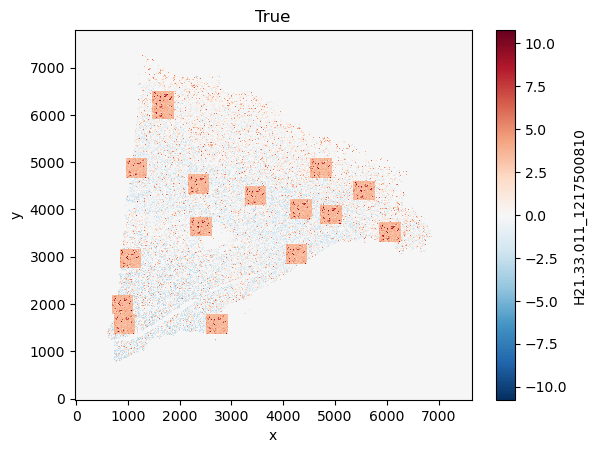

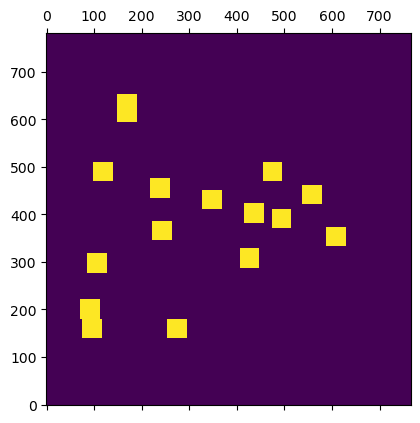

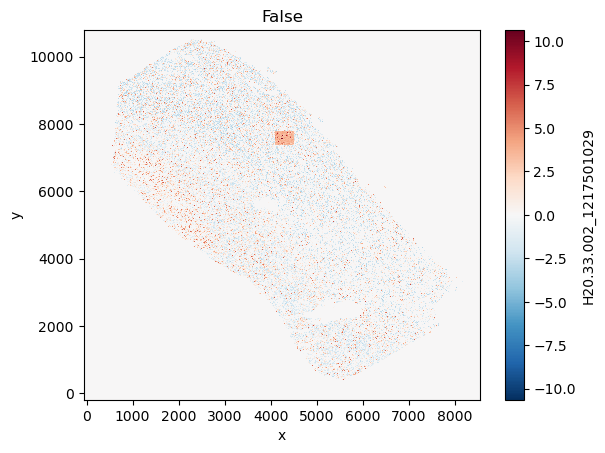

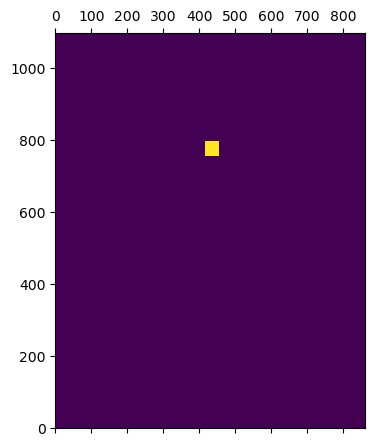

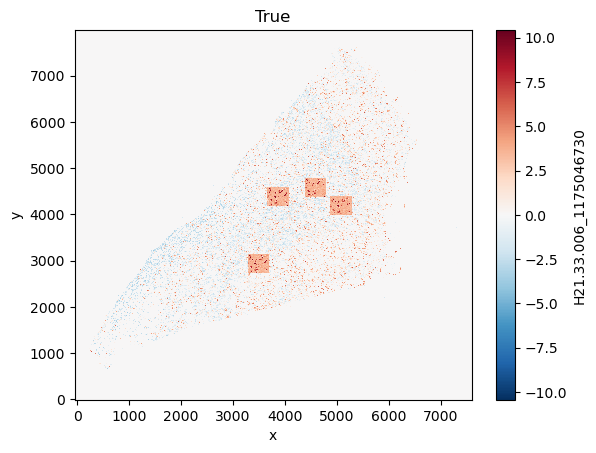

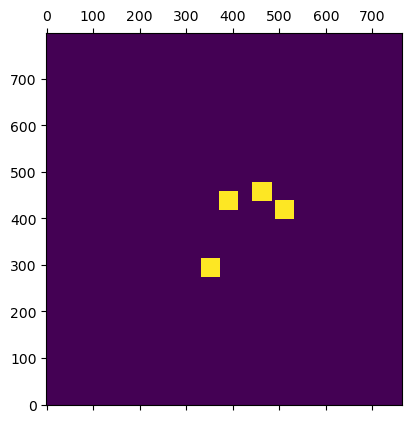

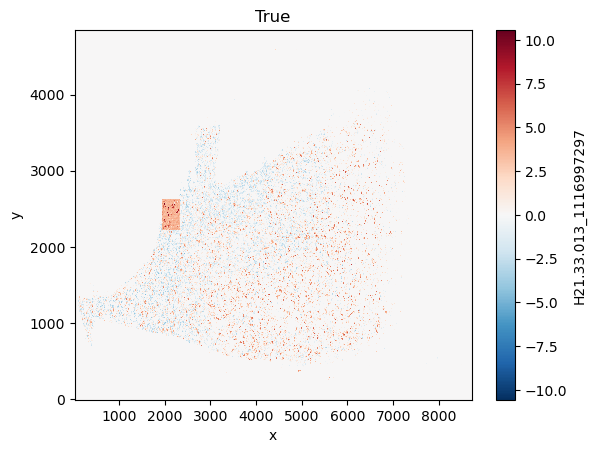

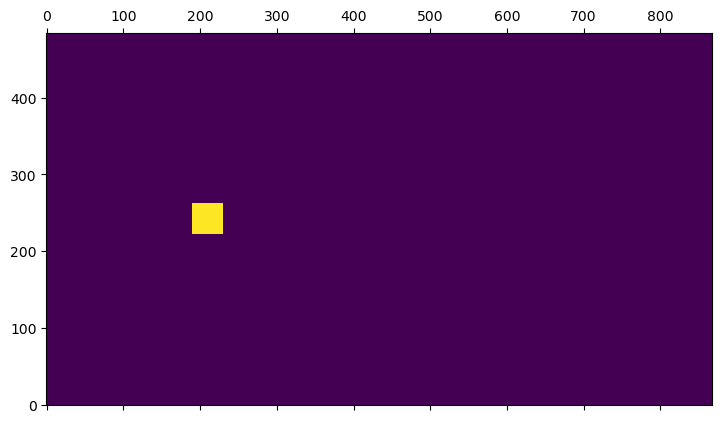

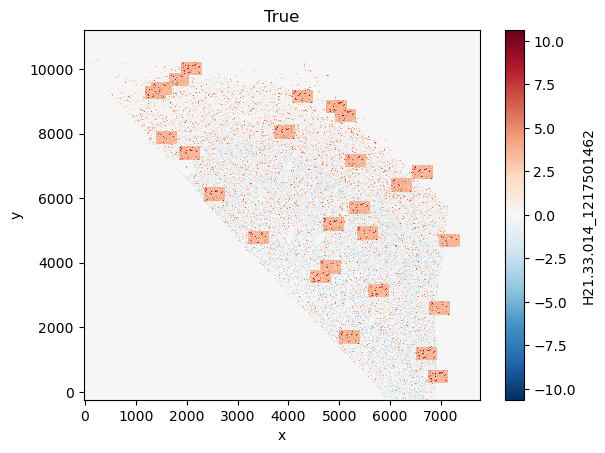

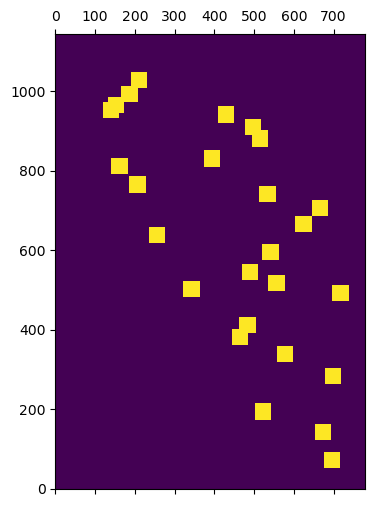

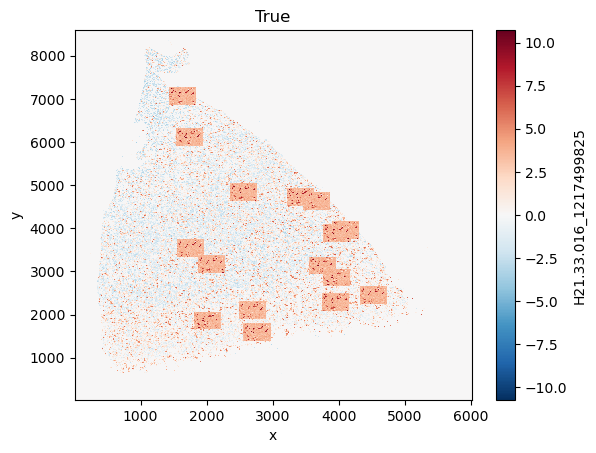

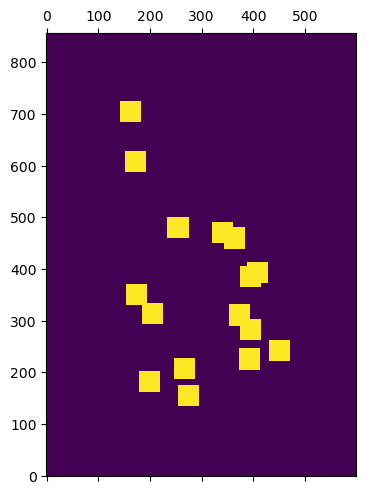

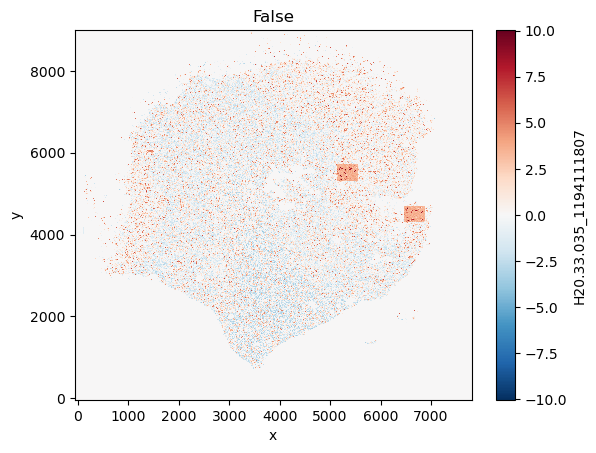

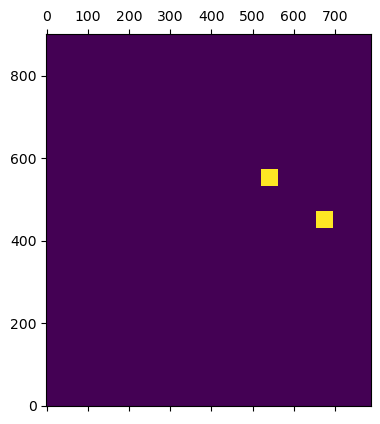

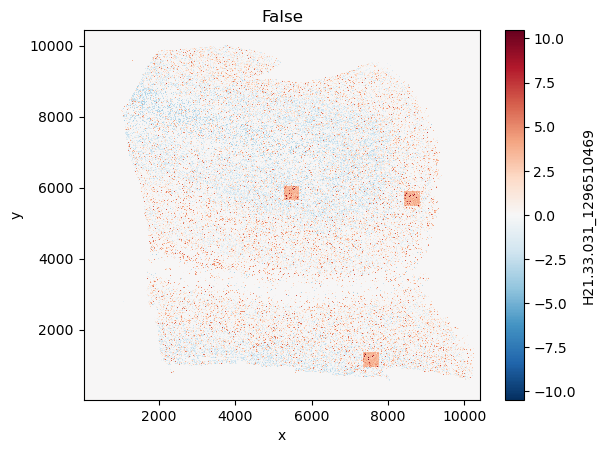

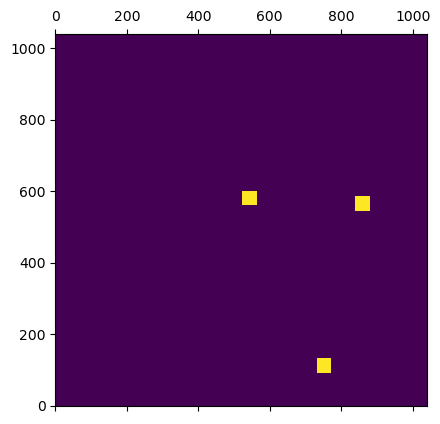

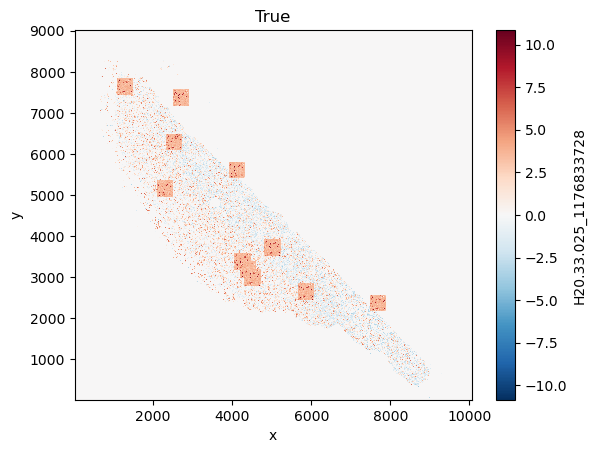

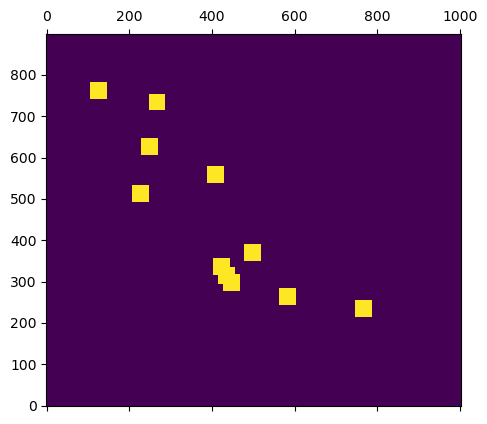

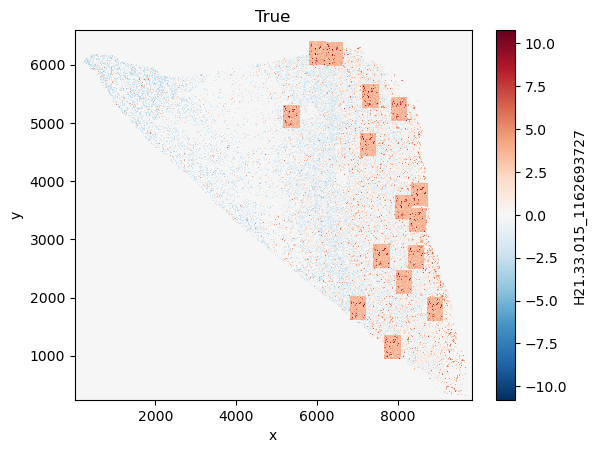

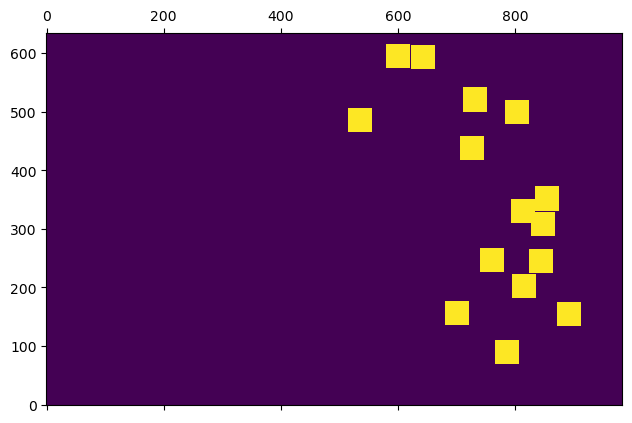

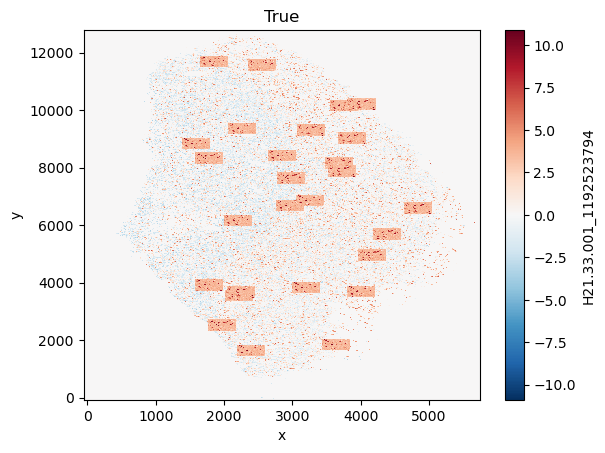

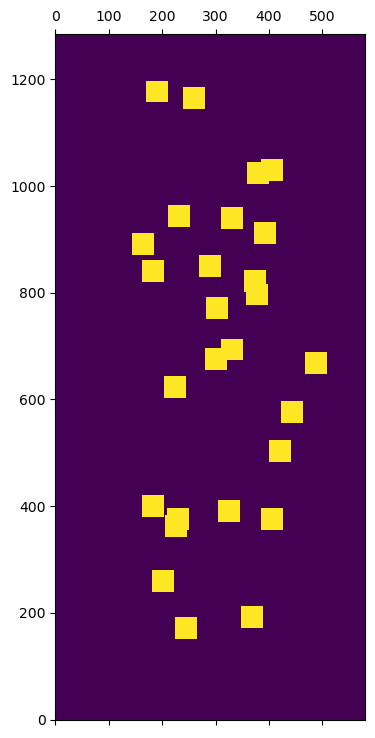

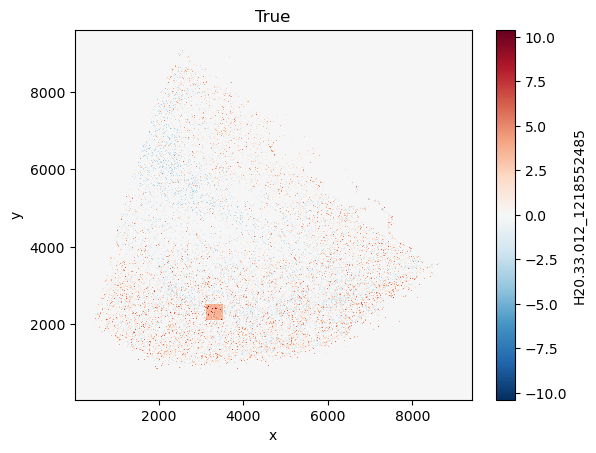

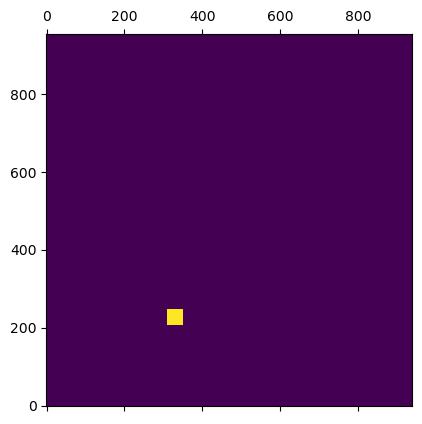

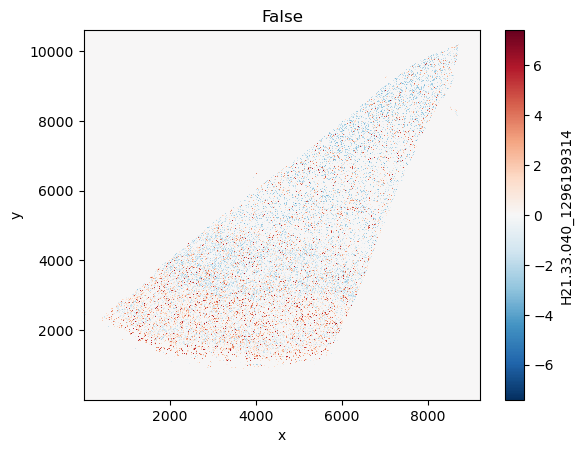

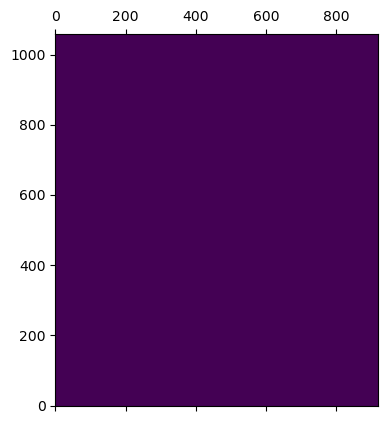

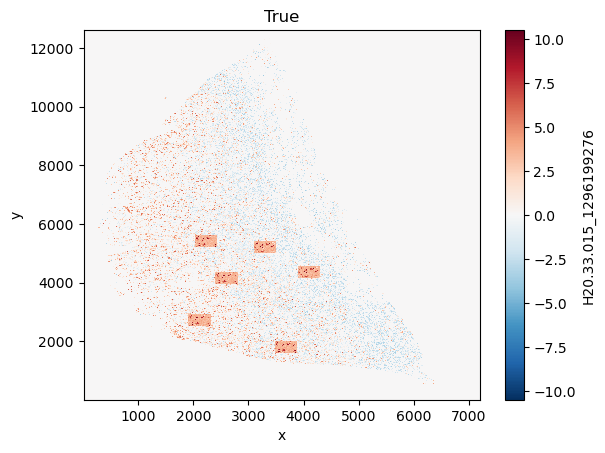

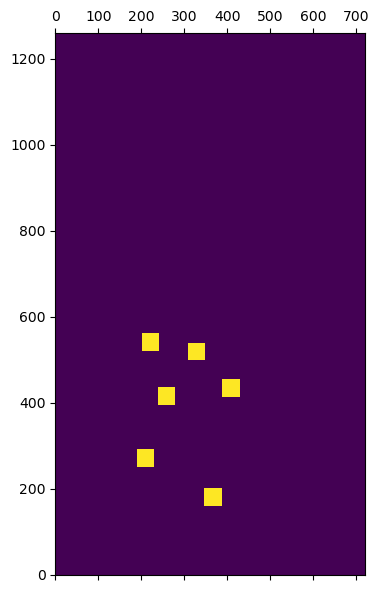

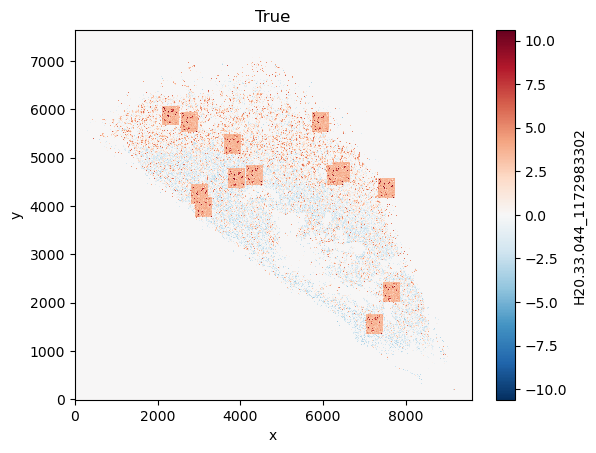

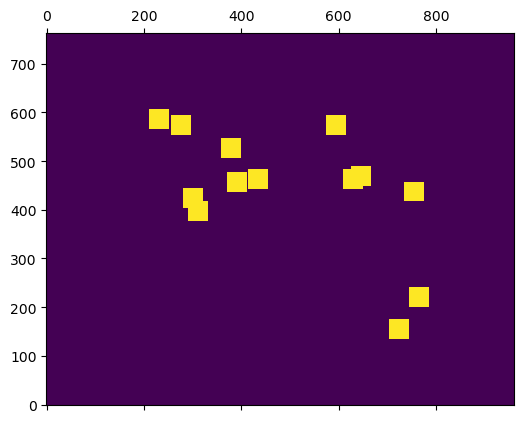

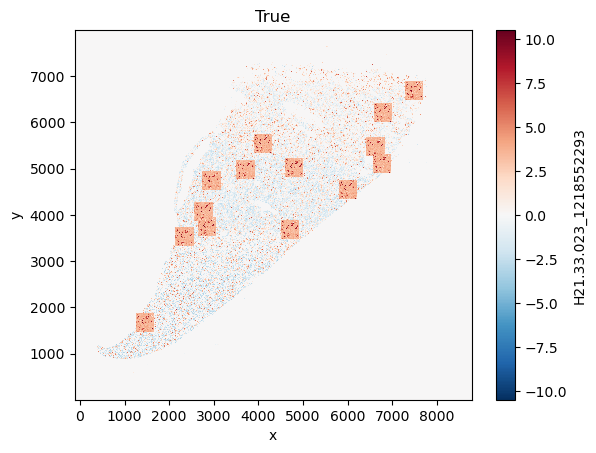

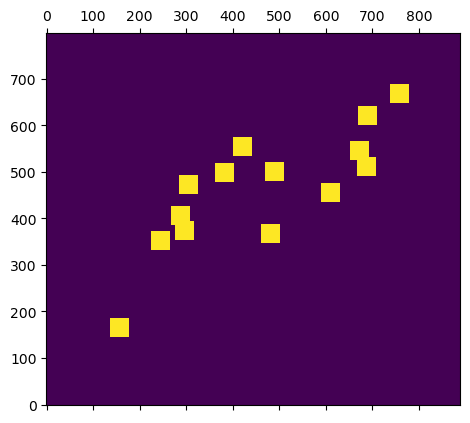

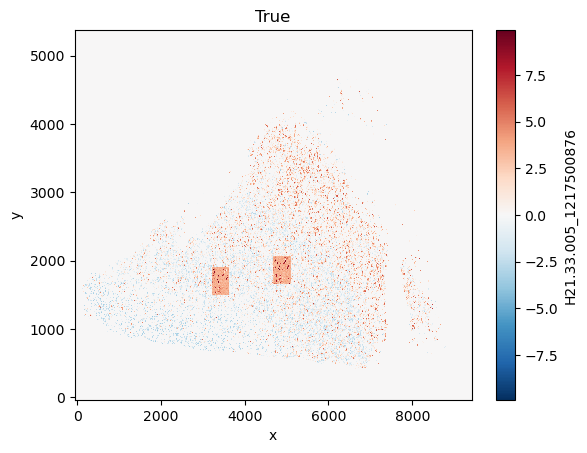

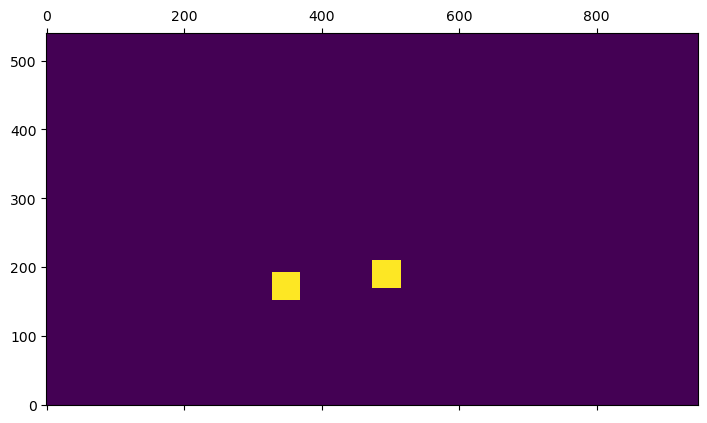

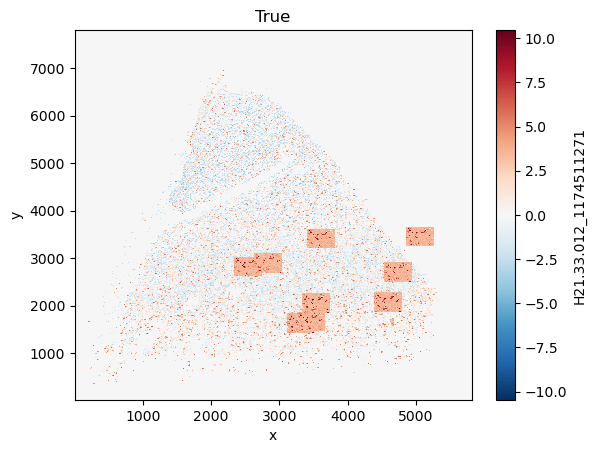

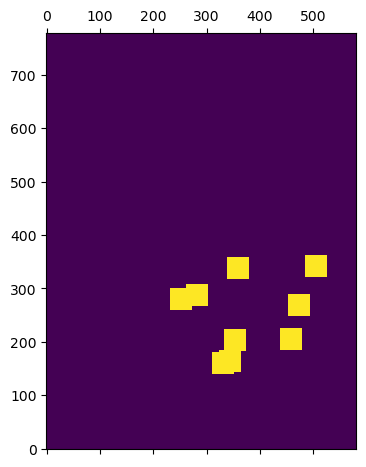

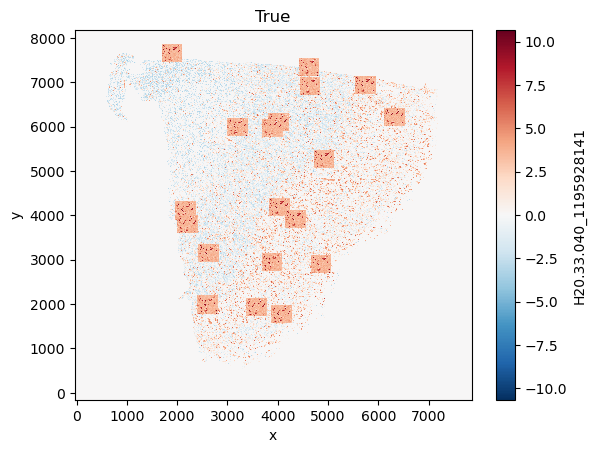

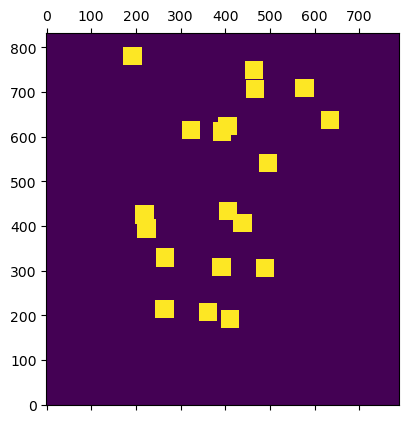

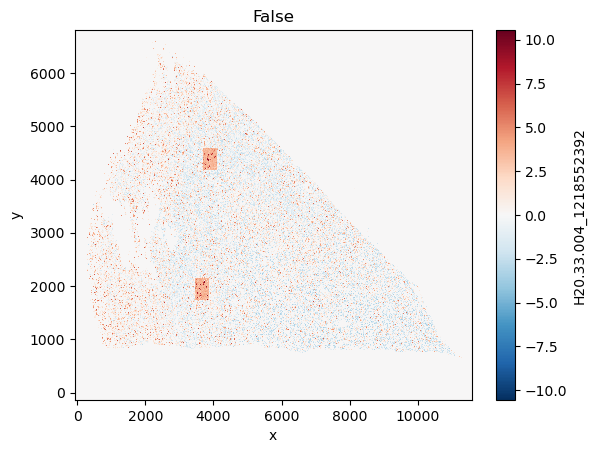

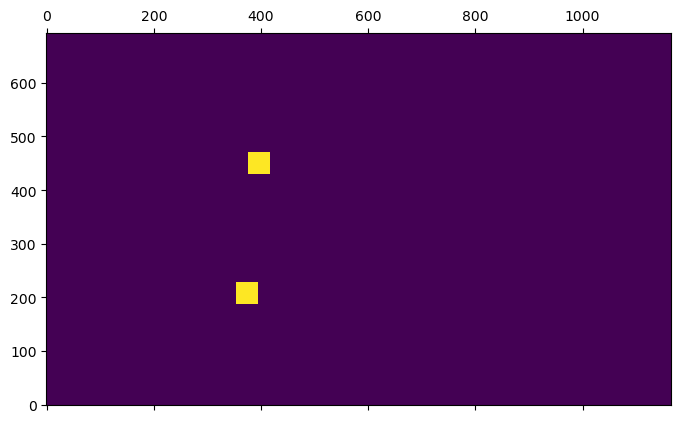

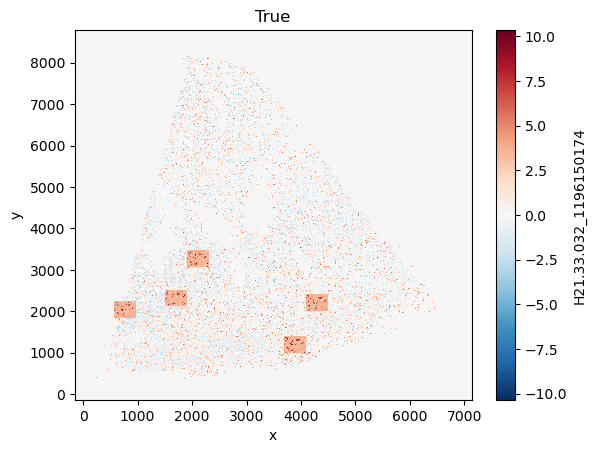

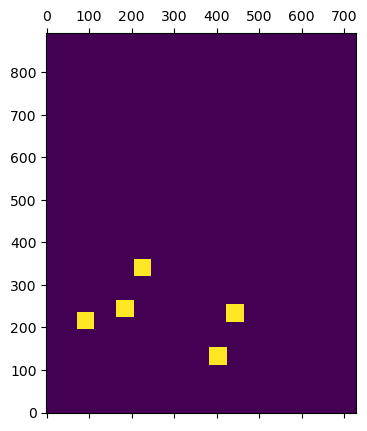

In [11]:
for s in filtered_samples.values():
    s.sel(marker='hPC2').plot(); plt.title(samplemeta.loc[s.sid,'case']); plt.show()
    plt.matshow(groundtruths[s.sid], origin='lower'); plt.show()

In [113]:
samples = filtered_samples

# choose which patches to train on
P = vima.PatchCollection(samples)
print(len(P), 'patches')

# choose which patches to do case/ctrl analysis on
Pdense = vima.PatchCollection(samples, max_frac_empty=0.5, sid_nums=P.sid_nums)
print(len(Pdense), 'dense patches')

# add in ground truth info
Pdense.meta['case'] = 0.
for sid in Pdense.meta.sid.unique():
    gt = groundtruths[sid]
    mask = Pdense.meta.sid == sid
    for idx, row in Pdense.meta[mask].iterrows():
        x, y, ps = row['x'], row['y'], row['patchsize']
        Pdense.meta.loc[idx, 'case'] = gt[y:y+ps, x:x+ps].mean()

100%|███████████████████████████████████████████████████████████████| 21/21 [00:07<00:00,  2.83it/s]


in pytorch mode
means: [ 0.09964252  0.30138177  0.02744541 -0.01195687  0.07068375 -0.040941
 -0.00623976 -0.04009412  0.02017894 -0.00881461]
stds: [1.4066398  1.5214394  1.0830234  1.0034899  0.91920775 0.92771184
 0.94376135 0.82198423 0.80210984 0.7809012 ]
data augmentation is off
57028 patches


100%|███████████████████████████████████████████████████████████████| 21/21 [00:04<00:00,  4.39it/s]


in pytorch mode
means: [ 0.27020124  0.45566142  0.01824925  0.03048868  0.07700537 -0.03587711
  0.01582835 -0.05648993  0.00960397 -0.00093326]
stds: [1.4924444  1.7394441  1.1983675  1.1344715  1.0225378  1.039122
 1.0314518  0.9171885  0.8847887  0.88535297]
data augmentation is off
33373 dense patches


21it [00:03,  6.10it/s]
/Users/yakir/Dropbox/py/vima/src/vima/data/samples.py:90: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


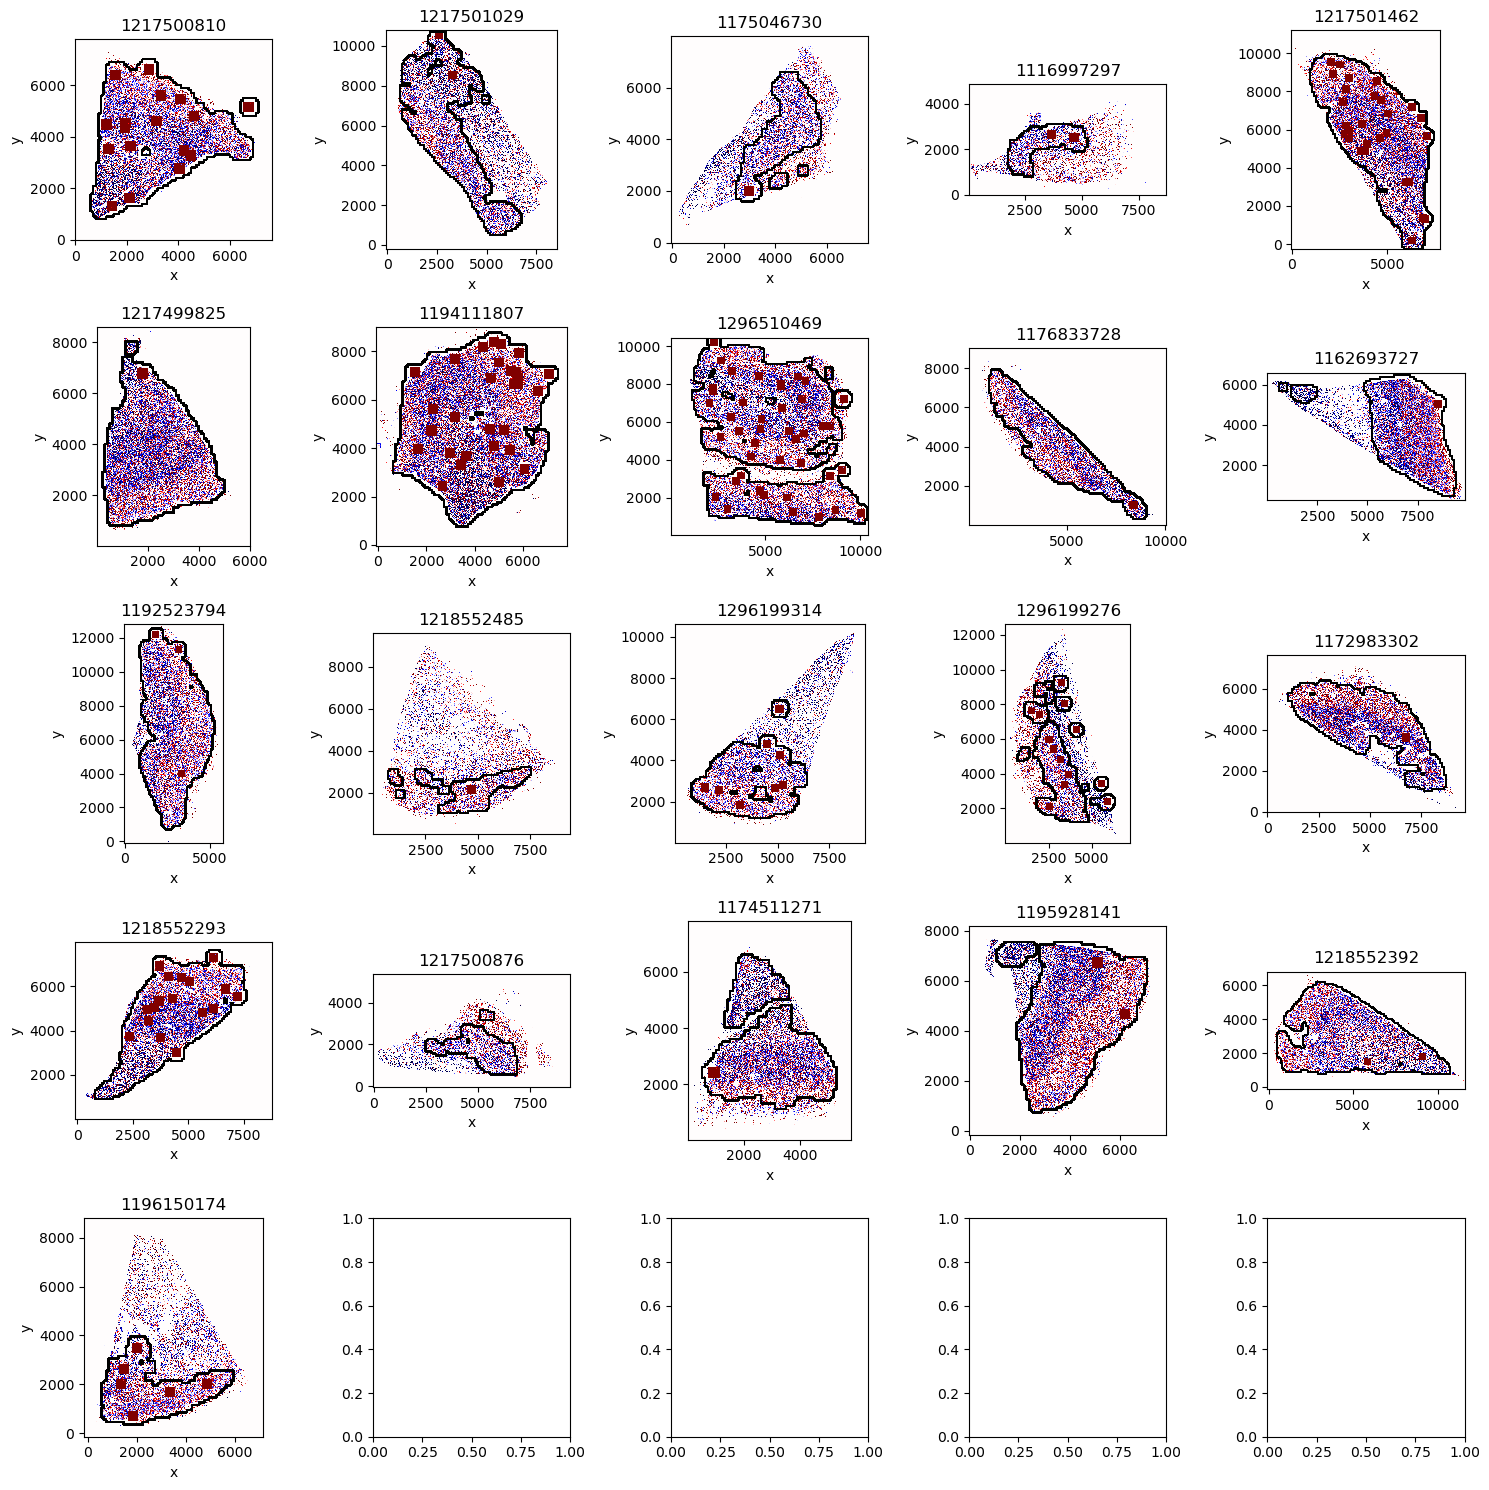

In [217]:
vima.d.plot_samples_with_patches(samples.values(), 'hPC2', Pdense.meta, ncols=5, vmin=-2, vmax=2, cmap='seismic')

end of epoch 20: avg val loss = 0.8711805939674377
time elapsed this epoch: 240.79 sec
total time elapsed: 5905.63 sec


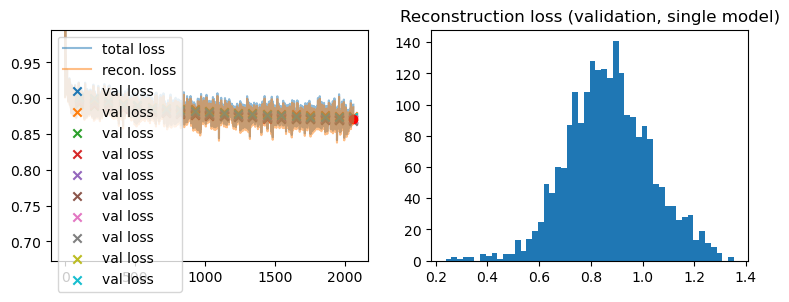

best validation losses so far across full model ensemble: [0.87059426, 0.8755003, 0.86950815, 0.8689239, 0.87065774, 0.8702588, 0.8707303, 0.86834866, 0.87381727, 0.8731835]
best epochs so far across full model ensemble: [20, 20, 20, 20, 19, 20, 20, 20, 20, 20]


In [218]:
models = vima.models.cVAE(P.nmarkers, P.nsamples)

log = vima.train(models, P, n_epochs=10)
log2 = vima.train(models, Pdense, n_epochs=20)
torch.save(models.state_dict(), f'_results/models.pt')

In [114]:
# load model
models = vima.models.cVAE(P.nmarkers, P.nsamples)
models.load_state_dict(torch.load(f'_results/models.pt'))

# apply models and build nearest-neighbor graphs
ds = vima.latentreps(models, Pdense)
# pickle.dump(ds, open(f'_results/fingerprints.pkl', 'wb'))

applying models
in pytorch mode
data augmentation is off


100%|███████████████████████████████████████████████████████████████| 34/34 [00:24<00:00,  1.37it/s]


computing nearest-neighbor graphs


100%|███████████████████████████████████████████████████████████████| 10/10 [00:29<00:00,  2.95s/it]


In [115]:
p, D = vima.association(ds, samplemeta.case.astype(float), 'sid')

computing MAT
performing association test
P = 0.00029997000299970003


/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


         Falling back to preprocessing with `sc.pp.pca` and default params.


In [ ]:
D.write('_results/D.h5ad')

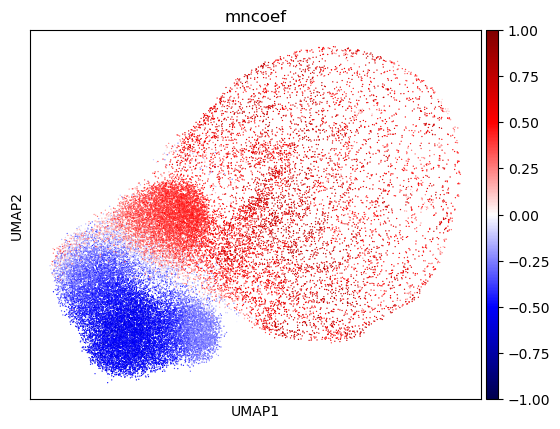

In [116]:
sc.pl.umap(D, color='mncoef', vmin=-1, vmax=1, cmap='seismic')

In [122]:
def roc_curve(d):
	nc = f'mncoef'
	fpr = []; tpr = []
	incr = (d.obs[nc].max()-d.obs[nc].min())/200
	for t in np.arange(d.obs[nc].min()-incr, d.obs[nc].max()+2*incr, incr):
		pos = d.obs.case > 0.1
		null = (d.obs.case <= 0.1)
		pred_pos = d.obs[nc] > t
		pred_null = d.obs[nc] <= t

		fpr.append((pred_pos & null).sum() / null.sum())
		tpr.append((pos & pred_pos).sum() / pos.sum())
	roc = pd.DataFrame({'fpr':fpr, 'tpr':tpr})
	roc = roc.dropna().sort_values(by='fpr')
	return np.trapz(roc.tpr, x=roc.fpr), roc

def auroc(d):
	return {
		'auroc': roc_curve(d)[0]
	}
def nfdr(d):
	return {
		'nfdr10': (d.obs[f'mncoef_fdr'] <= 0.1).sum()
	}
def truefdr(d):
	null_regions = d.obs[d.obs.case <= 0]
	nct = f'sig_mncoef'
	if (d.obs[nct] != 0).sum() == 0:
		fdr = 0
	else:
		fdr = (null_regions[nct] != 0).sum() / (d.obs[nct] != 0).sum()
	return {
		'truefdr' : fdr,
	}

def metrics(d):
	return auroc(d) | nfdr(d) | truefdr(d)

def metric_names():
	return ['auroc', 'nfdr10', 'truefdr']

In [124]:
D.obs['sig_mncoef'] = (D.obs['mncoef_fdr'] <= 0.05)*D.obs.mncoef
metrics(D)

{'auroc': 0.9373154649337271, 'nfdr10': 18498, 'truefdr': 0.5485944296565604}

In [119]:
((D.obs.mncoef_fdr <= 0.05) & (D.obs.case==0)).sum() / (D.obs.mncoef_fdr <= 0.05).sum()

0.5485944296565604

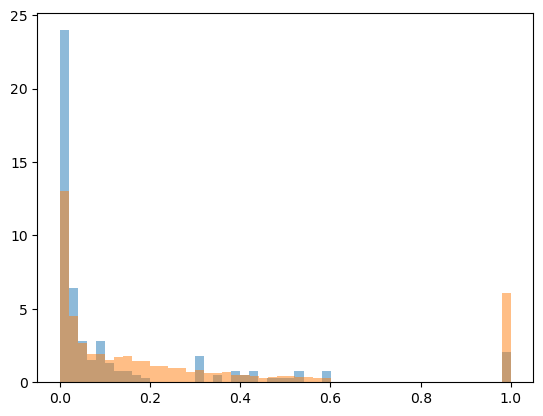

In [120]:
plt.hist(D.obs[D.obs.case > 0.9].mncoef_fdr, bins=50, density=True, alpha=0.5)
plt.hist(D.obs[D.obs.case == 0].mncoef_fdr, bins=50, density=True, alpha=0.5)
plt.show()

In [93]:
(D.obs.mncoef_fdr <= 0.05).mean()

0.284149169921875

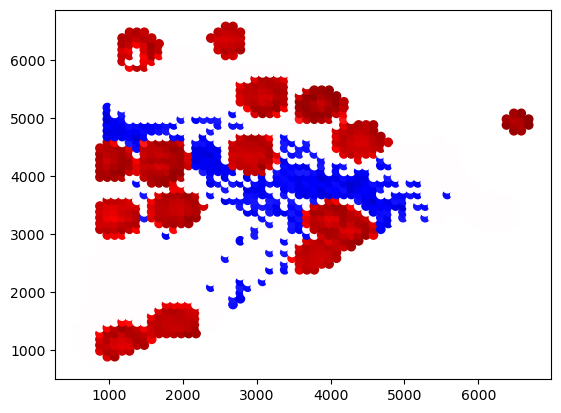

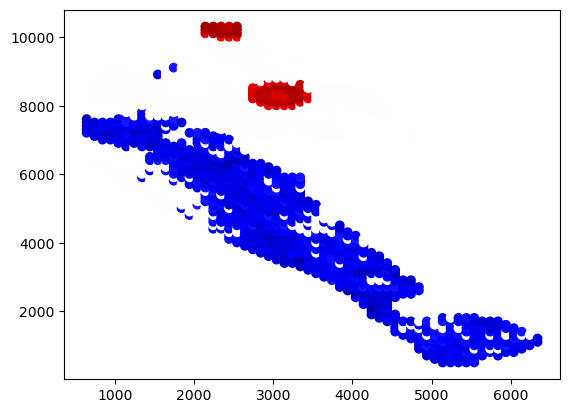

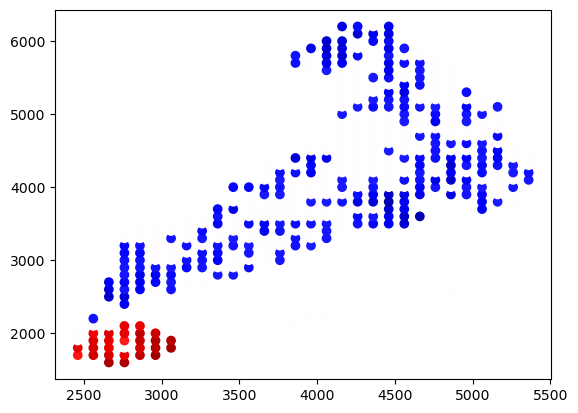

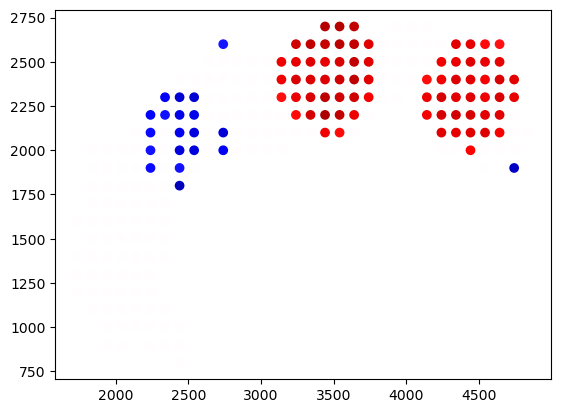

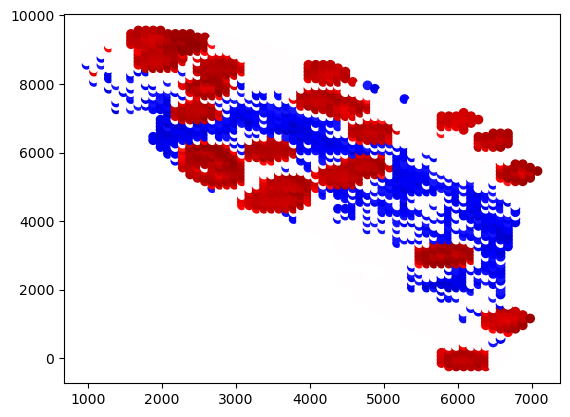

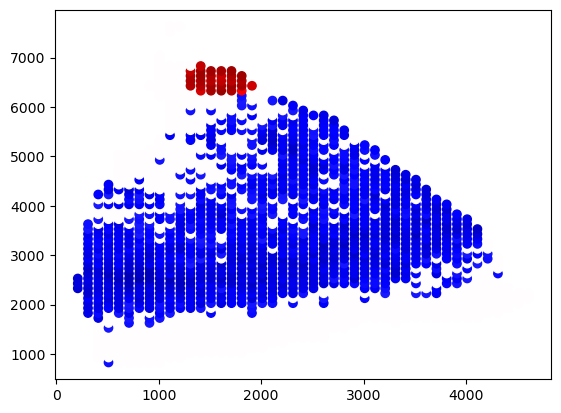

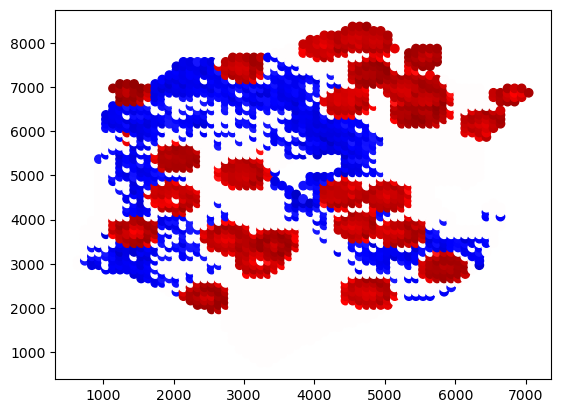

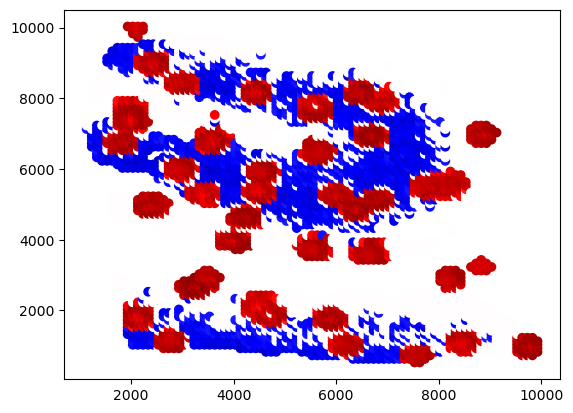

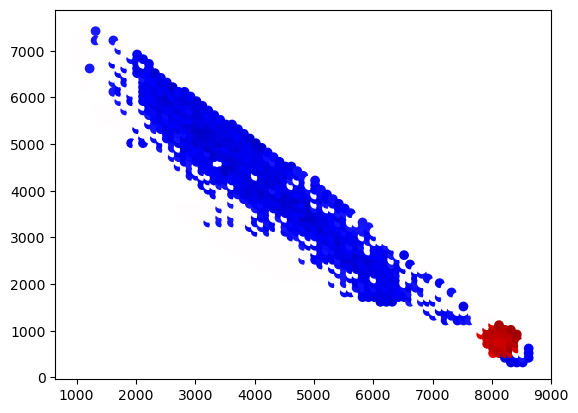

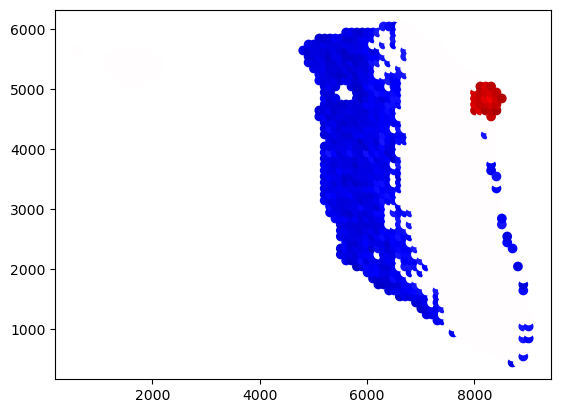

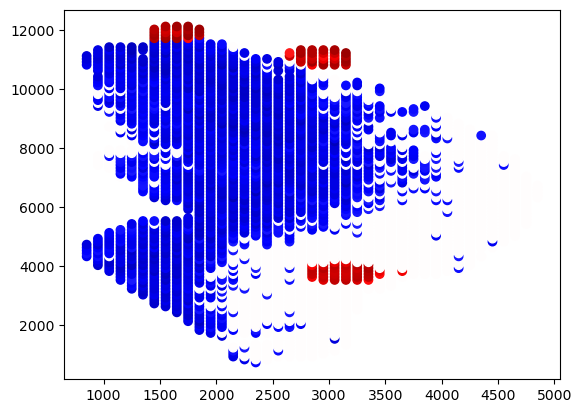

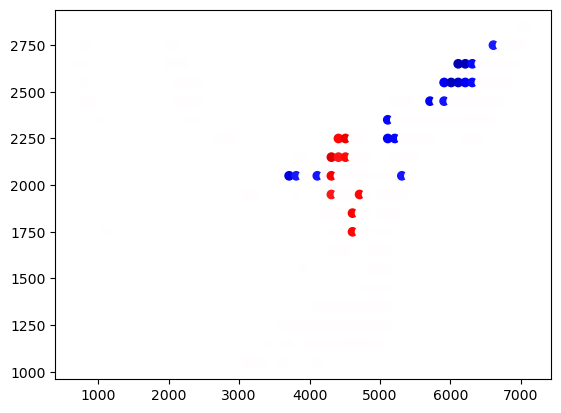

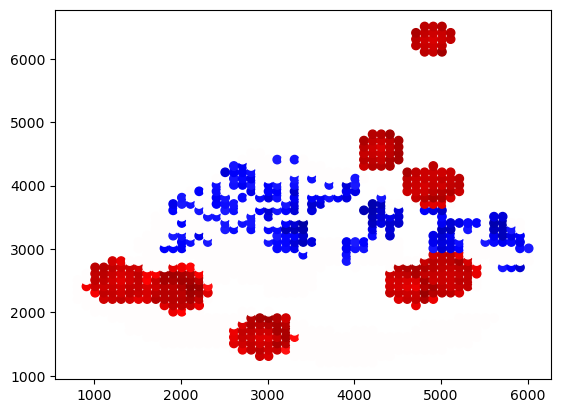

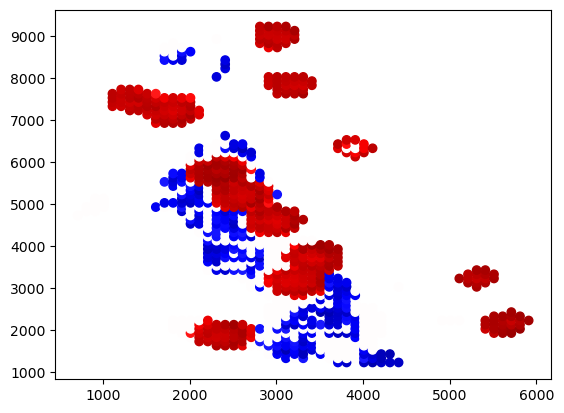

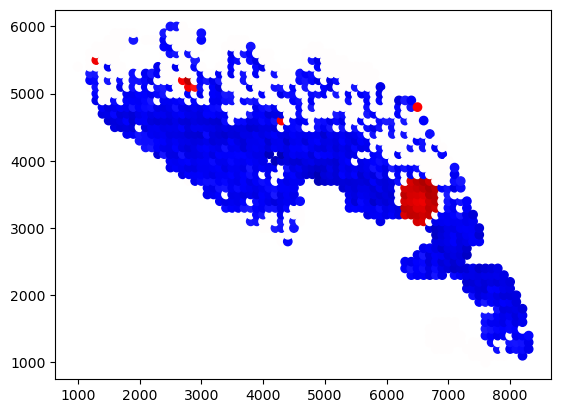

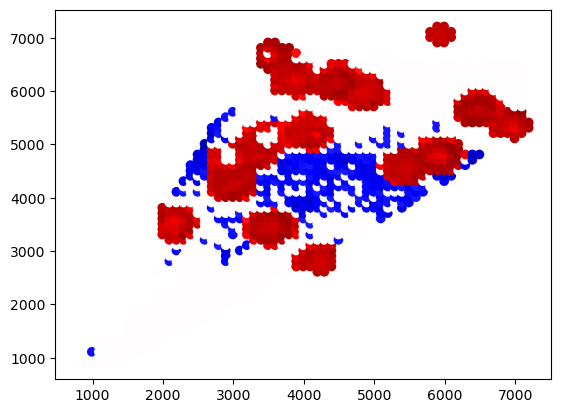

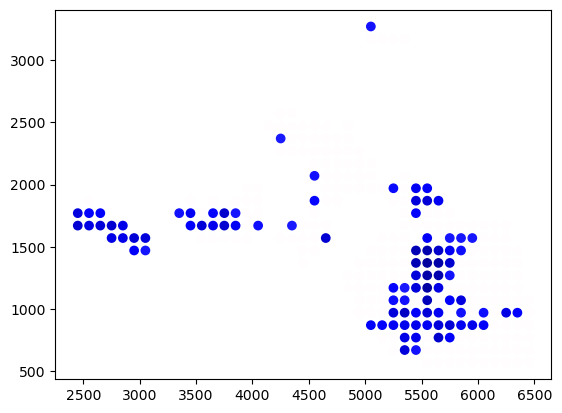

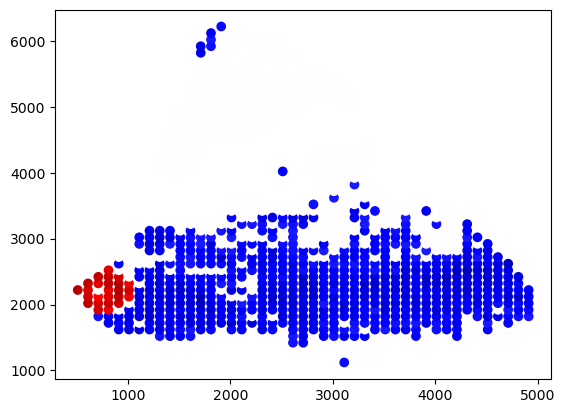

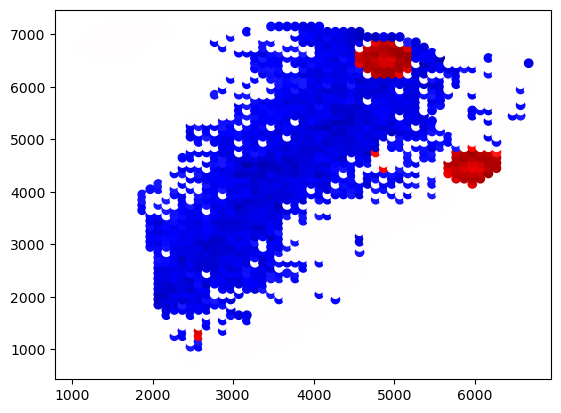

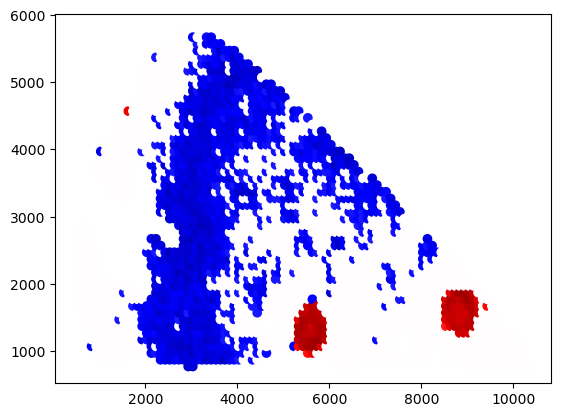

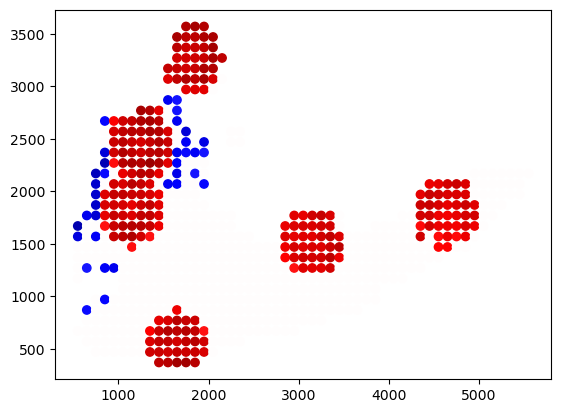

In [243]:
for sid in D.obs.sid.unique():
    dsub = D[D.obs.sid == sid]
    plt.scatter(dsub.obs.x_microns, dsub.obs.y_microns, c=dsub.obs.sig_mncoef, vmin=-1, vmax=1, cmap='seismic')
    plt.show()

In [ ]:
# store ground truth data for microniches
# compute spatial accuracy via AUC
# turn into one script with command line arguments
# ask chatgpt to help parallelize it on SLRUM
# upload data to O2
# install vima and ensure GPU is running
# hit play